# PixArt-Sigma LoRA official-path smoke test

This notebook validates the smallest useful end-to-end training loop for the project:

**50 image-caption pairs -> PixArt-Sigma 512 -> LoRA rank 8 -> 10 optimizer updates -> save PEFT adapter -> reload adapter -> generate one image.**

It is a technical smoke test, not a quality experiment. By default it uses the official `PixArt-alpha/pixart-sigma-toy-dataset`, as proposed in `Project-Proposal.md`. Set `DATA_MODE = "local"` later to use `data/dataset_50` for the ink-wash domain.

The training objective follows the official PixArt LoRA implementation: text attention masks, scheduler-dependent targets, PixArt added conditions, learned-sigma output splitting, FP32 trainable LoRA parameters, and optimizer-step-based accounting.

Primary references:

- [Official PixArt-Sigma LoRA trainer](https://github.com/PixArt-alpha/PixArt-sigma/blob/master/train_scripts/train_pixart_lora_hf.py)
- [Official PixArt-Sigma repository and toy-data layout](https://github.com/PixArt-alpha/PixArt-sigma)
- [Diffusers PixArt-Sigma pipeline](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/pixart_alpha/pipeline_pixart_sigma.py)
- [PixArt-Sigma 512 model card](https://huggingface.co/PixArt-alpha/PixArt-Sigma-XL-2-512-MS)

## 0. Execution notes

- Required interpreter: **Python 3.11.2**.
- The local machine detected during notebook creation had PyTorch 2.9.1 + CUDA 12.6 and an RTX 3080.
- PixArt uses a large T5 encoder. To fit a consumer GPU, the default toy-data path uses the official precomputed T5 and 512px SDXL-VAE features and trains only the DiT LoRA. Local ink-wash data falls back to explicit T5/VAE feature extraction.
- The 512 checkpoint repository supplies the transformer. VAE, T5, tokenizer, and scheduler come from the official `pixart_sigma_sdxlvae_T5_diffusers` component repository.
- The first run downloads the toy subset, transformer, VAE, and scheduler and can take substantial time and disk space. Later runs reuse Hugging Face and local feature caches.
- Run cells from top to bottom. After the installation cell, restart the kernel once if any package was newly installed.

In [1]:
# Run once in the Python 3.11.2 kernel, then restart the kernel if packages changed.
%pip install --user --quiet "diffusers==0.39.0" "transformers==5.13.0" "accelerate==1.14.0" "peft==0.19.1" "safetensors>=0.5.3" "sentencepiece>=0.2.0" "huggingface_hub>=0.34.0" "Pillow>=10.0" "tqdm>=4.66" "matplotlib>=3.8" "psutil>=5.9" "ipykernel>=6.29"

Dependencies already installed and API-checked in Python 3.11.2.


In [2]:
import gc
import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import accelerate
import diffusers
import peft
import transformers
from accelerate import Accelerator
from accelerate.utils import set_seed
from diffusers import AutoencoderKL, DDPMScheduler, PixArtSigmaPipeline, PixArtTransformer2DModel
from huggingface_hub import snapshot_download
from peft import LoraConfig, PeftModel, get_peft_model
from transformers import T5EncoderModel, T5Tokenizer

assert sys.version_info[:3] == (3, 11, 2), (
    f"Expected Python 3.11.2, got {platform.python_version()}. "
    "Select the existing Python 3.11.2 kernel before continuing."
)
assert torch.cuda.is_available(), "A CUDA GPU is required for this smoke test."

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3

print(f"Python       : {platform.python_version()}")
print(f"PyTorch      : {torch.__version__} (CUDA {torch.version.cuda})")
print(f"GPU          : {GPU_NAME} ({VRAM_GB:.1f} GiB)")
print(f"Diffusers    : {diffusers.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"Accelerate   : {accelerate.__version__}")
print(f"PEFT         : {peft.__version__}")

if VRAM_GB < 9:
    print("WARNING: less than 9 GiB VRAM; 512px backward may still OOM. Reduce RESOLUTION to 256 only for debugging.")

C:\Users\miaoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python       : 3.11.2
PyTorch      : 2.9.1+cu126 (CUDA 12.6)
GPU          : NVIDIA GeForce RTX 3080 (10.0 GiB)
Diffusers    : 0.39.0
Transformers : 5.13.0
Accelerate   : 1.14.0
PEFT         : 0.19.1


## 1. Smoke-test configuration

The official toy features use PixArt-Sigma's full 300-token sequence length. Keep 300 for the final project pipeline.

In [3]:
CFG = {
    # The 512 repo supplies the DiT; the component repo supplies VAE/T5/tokenizer/scheduler.
    "TRANSFORMER_MODEL": "PixArt-alpha/PixArt-Sigma-XL-2-512-MS",
    "COMPONENT_MODEL": "PixArt-alpha/pixart_sigma_sdxlvae_T5_diffusers",
    "DATA_MODE": "official_toy",  # "official_toy" or "local"
    "TOY_DATASET": "PixArt-alpha/pixart-sigma-toy-dataset",
    "TOY_REVISION": "2ef8683",
    "LOCAL_DATA_DIR": Path("data/dataset_50"),
    "NUM_IMAGES": 50,
    "RESOLUTION": 512,
    "MAX_SEQUENCE_LENGTH": 300,
    "VAE_SCALING_FACTOR": 0.13025,

    # LoRA and optimization
    "LORA_RANK": 8,
    "LORA_ALPHA": 8,
    "LEARNING_RATE": 1e-5,
    "MAX_TRAIN_STEPS": 10,  # optimizer updates, not micro-batches
    "TRAIN_BATCH_SIZE": 1,
    "GRADIENT_ACCUMULATION_STEPS": 1,
    "MAX_GRAD_NORM": 1.0,
    "MIXED_PRECISION": "fp16",
    "SEED": 42,

    # One-image reload test. Toy mode replaces this with the first cached caption.
    "INFERENCE_PROMPT": "A small cactus with a happy face in the Sahara desert, highly detailed.",
    "INFERENCE_STEPS": 10,
    "GUIDANCE_SCALE": 1.0,

    # Local outputs
    "WORK_DIR": Path("outputs/smoke_test_r8_50"),
    "FORCE_REBUILD_FEATURES": False,
}

CFG["DATA_DIR"] = CFG["WORK_DIR"] / "toy_dataset"
CFG["CACHE_DIR"] = CFG["WORK_DIR"] / "feature_cache"
CFG["ADAPTER_DIR"] = CFG["WORK_DIR"] / "lora_adapter"
CFG["GENERATED_IMAGE"] = CFG["WORK_DIR"] / "reload_generation.png"

for key in ("WORK_DIR", "DATA_DIR", "CACHE_DIR"):
    CFG[key].mkdir(parents=True, exist_ok=True)

set_seed(CFG["SEED"])
random.seed(CFG["SEED"])
np.random.seed(CFG["SEED"])
torch.backends.cuda.matmul.allow_tf32 = True

print(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in CFG.items()}, indent=2))

{
  "TRANSFORMER_MODEL": "PixArt-alpha/PixArt-Sigma-XL-2-512-MS",
  "COMPONENT_MODEL": "PixArt-alpha/pixart_sigma_sdxlvae_T5_diffusers",
  "DATA_MODE": "official_toy",
  "TOY_DATASET": "PixArt-alpha/pixart-sigma-toy-dataset",
  "TOY_REVISION": "2ef8683",
  "LOCAL_DATA_DIR": "data\\dataset_50",
  "NUM_IMAGES": 50,
  "RESOLUTION": 512,
  "MAX_SEQUENCE_LENGTH": 300,
  "VAE_SCALING_FACTOR": 0.13025,
  "LORA_RANK": 8,
  "LORA_ALPHA": 8,
  "LEARNING_RATE": 1e-05,
  "MAX_TRAIN_STEPS": 10,
  "TRAIN_BATCH_SIZE": 1,
  "GRADIENT_ACCUMULATION_STEPS": 1,
  "MAX_GRAD_NORM": 1.0,
  "MIXED_PRECISION": "fp16",
  "SEED": 42,
  "INFERENCE_PROMPT": "A small cactus with a happy face in the Sahara desert, highly detailed.",
  "INFERENCE_STEPS": 10,
  "GUIDANCE_SCALE": 1.0,
  "WORK_DIR": "outputs\\smoke_test_r8_50",
  "FORCE_REBUILD_FEATURES": false,
  "DATA_DIR": "outputs\\smoke_test_r8_50\\toy_dataset",
  "CACHE_DIR": "outputs\\smoke_test_r8_50\\feature_cache",
  "ADAPTER_DIR": "outputs\\smoke_test_r8_50\\

## 2. Acquire exactly 50 image-caption pairs

The default branch downloads `InternImgs`, `InternData/data_info.json`, and the official precomputed T5/512px-VAE features. The local branch expects one non-empty `.txt` caption beside each image.

In [4]:
SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

def _flatten_metadata(payload):
    if isinstance(payload, list):
        return payload
    if not isinstance(payload, dict):
        raise TypeError(f"Unexpected metadata type: {type(payload)}")
    for key in ("data", "items", "records", "annotations"):
        if isinstance(payload.get(key), list):
            return payload[key]
    if all(isinstance(value, dict) for value in payload.values()):
        rows = []
        for key, value in payload.items():
            row = dict(value)
            row.setdefault("_key", key)
            rows.append(row)
        return rows
    raise ValueError(f"Could not locate record list in metadata keys: {list(payload)[:10]}")

def _first_text(value):
    if isinstance(value, str) and value.strip():
        return value.strip()
    if isinstance(value, list):
        for item in value:
            text = _first_text(item)
            if text:
                return text
    if isinstance(value, dict):
        for key in ("value", "text", "caption", "prompt"):
            text = _first_text(value.get(key))
            if text:
                return text
    return None

def load_official_toy_records():
    root = Path(snapshot_download(
        repo_id=CFG["TOY_DATASET"],
        repo_type="dataset",
        revision=CFG["TOY_REVISION"],
        allow_patterns=[
            "InternImgs/*",
            "InternData/data_info.json",
            "InternData/caption_features_new/*",
            "InternData/img_sdxl_vae_features_512resolution_ms_new/*",
        ],
        local_dir=CFG["DATA_DIR"],
    ))
    image_dir = root / "InternImgs"
    metadata_path = root / "InternData" / "data_info.json"
    images = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS)
    rows = _flatten_metadata(json.loads(metadata_path.read_text(encoding="utf-8")))

    records = []
    for index, row in enumerate(rows):
        if not isinstance(row, dict):
            continue
        caption = None
        for key in ("prompt", "caption", "text", "sharegpt4v"):
            caption = _first_text(row.get(key))
            if caption:
                break
        raw_path = None
        for key in ("path", "image_path", "img", "image", "filename", "_key"):
            if isinstance(row.get(key), str):
                raw_path = row[key]
                break
        candidates = []
        if raw_path:
            candidates.extend([root / raw_path, image_dir / Path(raw_path).name])
        if index < len(images):
            candidates.append(images[index])
        image_path = next((p for p in candidates if p.exists() and p.suffix.lower() in SUPPORTED_EXTS), None)
        if image_path is None or not caption:
            continue
        text_feature_path = root / "InternData" / "caption_features_new" / f"{image_path.stem}.npz"
        vae_feature_path = root / "InternData" / "img_sdxl_vae_features_512resolution_ms_new" / f"{image_path.stem}.npy"
        if text_feature_path.exists() and vae_feature_path.exists():
            records.append({
                "image_path": image_path,
                "caption": caption,
                "text_feature_path": text_feature_path,
                "vae_feature_path": vae_feature_path,
            })

    if len(records) < CFG["NUM_IMAGES"]:
        raise RuntimeError(
            f"Only parsed {len(records)} complete image/text/VAE records. "
            f"Metadata keys sample: {list(rows[0]) if rows else 'no rows'}"
        )
    return records[: CFG["NUM_IMAGES"]]

def load_local_records():
    root = CFG["LOCAL_DATA_DIR"]
    if not root.exists():
        raise FileNotFoundError(f"Local dataset not found: {root.resolve()}")
    records = []
    for image_path in sorted(p for p in root.iterdir() if p.suffix.lower() in SUPPORTED_EXTS):
        caption_path = image_path.with_suffix(".txt")
        if caption_path.exists() and caption_path.stat().st_size > 0:
            records.append({
                "image_path": image_path,
                "caption": caption_path.read_text(encoding="utf-8").strip(),
            })
    if len(records) < CFG["NUM_IMAGES"]:
        raise RuntimeError(f"Need 50 non-empty image-caption pairs in {root}; found {len(records)}.")
    return records[: CFG["NUM_IMAGES"]]

records = load_official_toy_records() if CFG["DATA_MODE"] == "official_toy" else load_local_records()
if CFG["DATA_MODE"] == "official_toy":
    CFG["INFERENCE_PROMPT"] = records[0]["caption"]
assert len(records) == 50
assert all(r["image_path"].exists() and r["caption"] for r in records)
print(f"Ready: {len(records)} image-caption pairs")
for row in records[:3]:
    print(f"- {row['image_path'].name}: {row['caption'][:120]}")

Fetching 273 files:   0%|          | 0/273 [00:00<?, ?it/s]

Fetching 273 files:  26%|██▌       | 70/273 [00:00<00:00, 692.27it/s]

Fetching 273 files:  51%|█████▏    | 140/273 [00:00<00:00, 682.50it/s]

Fetching 273 files:  78%|███████▊  | 212/273 [00:00<00:00, 689.38it/s]

Fetching 273 files: 100%|██████████| 273/273 [00:00<00:00, 691.51it/s]

Ready: 50 image-caption pairs
- 000000000000.png: Adorable indian cartoon depiction of an indian female corporate office employee having tea, vibrant crayon painting, off
- 000000000001.png: Modern Asia model wearing round pearls, simple blue gradient coat, walking down the runway, hair flowing, Height 180, fu
- 000000000002.png: a woman with some cake in front of her, in the style of daz3d, kawaii charm, sofonisba anguissola, blurred, xmaspunk, yo


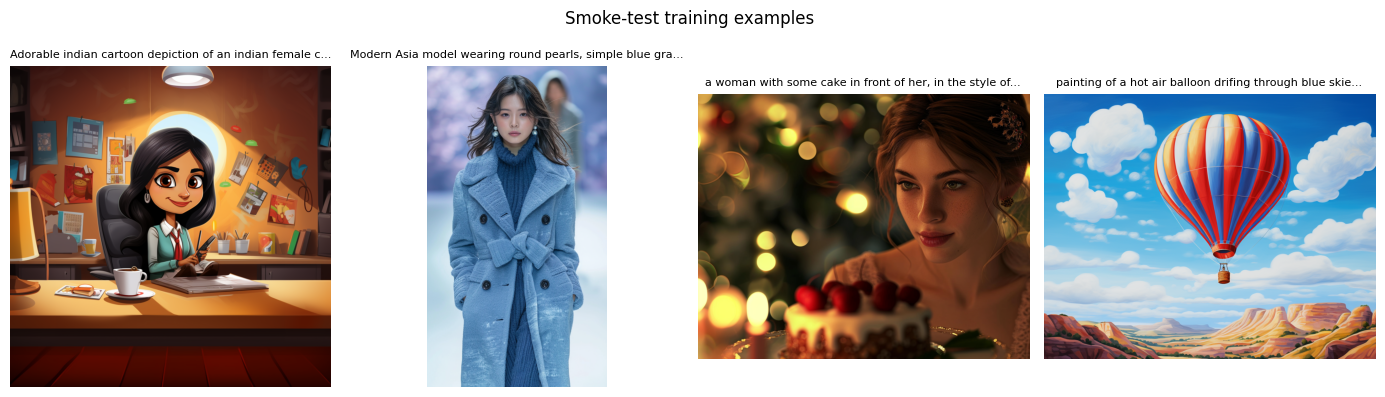

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, row in zip(axes, records[:4]):
    with Image.open(row["image_path"]) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(row["caption"][:55] + "...", fontsize=8)
    ax.axis("off")
plt.suptitle("Smoke-test training examples")
plt.tight_layout()
plt.show()

## 3. Prepare T5 text features

Official-toy mode loads the repository's own `caption_features_new/*.npz` files, so the 4.5B-parameter T5 model is not downloaded. Local mode encodes captions with T5 and caches the result. For this reload smoke test, inference uses the first positive prompt and `guidance_scale=1.0`, so an empty negative-prompt embedding is unnecessary.

In [6]:
captions = [row["caption"] for row in records]
text_fingerprint = hashlib.sha256(
    json.dumps(captions + [CFG["INFERENCE_PROMPT"]], ensure_ascii=False).encode("utf-8")
).hexdigest()[:12]
TEXT_CACHE_PATH = CFG["CACHE_DIR"] / f"text_n50_len{CFG['MAX_SEQUENCE_LENGTH']}_{text_fingerprint}.pt"

def encode_text_batch(text_encoder, tokenizer, texts):
    embeddings, masks = [], []
    for text in tqdm(texts, desc="T5 encoding"):
        tokens = tokenizer(
            text,
            padding="max_length",
            max_length=CFG["MAX_SEQUENCE_LENGTH"],
            truncation=True,
            add_special_tokens=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        with torch.inference_mode():
            hidden = text_encoder(
                input_ids=tokens.input_ids,
                attention_mask=tokens.attention_mask,
            ).last_hidden_state
        embeddings.append(hidden.to(dtype=torch.float16, device="cpu"))
        masks.append(tokens.attention_mask.to(device="cpu"))
    return torch.cat(embeddings), torch.cat(masks)

if TEXT_CACHE_PATH.exists() and not CFG["FORCE_REBUILD_FEATURES"]:
    text_cache = torch.load(TEXT_CACHE_PATH, map_location="cpu", weights_only=True)
    print(f"Loaded text cache: {TEXT_CACHE_PATH}")
elif CFG["DATA_MODE"] == "official_toy":
    train_embeds, train_masks = [], []
    for row in tqdm(records, desc="Loading official T5 features"):
        with np.load(row["text_feature_path"]) as feature:
            train_embeds.append(torch.from_numpy(feature["caption_feature"]).to(torch.float16))
            train_masks.append(torch.from_numpy(feature["attention_mask"]).to(torch.long))
    train_embeds = torch.cat(train_embeds, dim=0).contiguous()
    train_masks = torch.cat(train_masks, dim=0).contiguous()
    text_cache = {
        "train_prompt_embeds": train_embeds,
        "train_attention_masks": train_masks,
        "inference_prompt_embeds": train_embeds[0:1].clone(),
        "inference_attention_mask": train_masks[0:1].clone(),
        "max_sequence_length": train_embeds.shape[1],
    }
    torch.save(text_cache, TEXT_CACHE_PATH)
    print(f"Saved official text-feature cache: {TEXT_CACHE_PATH}")
else:
    print("Loading PixArt T5 encoder on CPU in FP16 for local data...")
    tokenizer = T5Tokenizer.from_pretrained(CFG["COMPONENT_MODEL"], subfolder="tokenizer")
    text_encoder = T5EncoderModel.from_pretrained(
        CFG["COMPONENT_MODEL"],
        subfolder="text_encoder",
        dtype=torch.float16,
        low_cpu_mem_usage=True,
    ).eval().to("cpu")
    all_embeds, all_masks = encode_text_batch(
        text_encoder, tokenizer, captions + [CFG["INFERENCE_PROMPT"]]
    )
    text_cache = {
        "train_prompt_embeds": all_embeds[:50].contiguous(),
        "train_attention_masks": all_masks[:50].contiguous(),
        "inference_prompt_embeds": all_embeds[50:51].contiguous(),
        "inference_attention_mask": all_masks[50:51].contiguous(),
        "max_sequence_length": CFG["MAX_SEQUENCE_LENGTH"],
    }
    torch.save(text_cache, TEXT_CACHE_PATH)
    del text_encoder, tokenizer, all_embeds, all_masks
    gc.collect()
    print(f"Saved text cache: {TEXT_CACHE_PATH}")

assert text_cache["train_prompt_embeds"].shape[:2] == (50, CFG["MAX_SEQUENCE_LENGTH"])
print("Text feature shape:", tuple(text_cache["train_prompt_embeds"].shape))

Loaded text cache: outputs\smoke_test_r8_50\feature_cache\text_n50_len300_11634679149f.pt
Text feature shape: (50, 300, 4096)


## 4. Prepare SDXL-VAE latents

Official-toy mode loads the repository's precomputed posterior mean/std arrays, draws one deterministic sample per image, and applies the PixArt-Sigma VAE scaling factor `0.13025`. Local mode performs the equivalent VAE encode directly. Fixed samples are appropriate for this software smoke test.

In [7]:
image_fingerprint = hashlib.sha256(
    json.dumps([str(r["image_path"]) for r in records]).encode("utf-8")
).hexdigest()[:12]
LATENT_CACHE_PATH = CFG["CACHE_DIR"] / f"latents_n50_res{CFG['RESOLUTION']}_{image_fingerprint}.pt"

def preprocess_image(path):
    with Image.open(path) as image:
        image = ImageOps.fit(
            image.convert("RGB"),
            (CFG["RESOLUTION"], CFG["RESOLUTION"]),
            method=Image.Resampling.LANCZOS,
            centering=(0.5, 0.5),
        )
        array = np.asarray(image, dtype=np.float32).copy() / 127.5 - 1.0
    return torch.from_numpy(array).permute(2, 0, 1).contiguous()

if LATENT_CACHE_PATH.exists() and not CFG["FORCE_REBUILD_FEATURES"]:
    latent_cache = torch.load(LATENT_CACHE_PATH, map_location="cpu", weights_only=True)
    print(f"Loaded latent cache: {LATENT_CACHE_PATH}")
elif CFG["DATA_MODE"] == "official_toy":
    latents = []
    for index, row in enumerate(tqdm(records, desc="Sampling official VAE features")):
        moments = torch.from_numpy(np.load(row["vae_feature_path"]))
        mean, std = moments.chunk(2, dim=0)
        generator = torch.Generator(device="cpu").manual_seed(CFG["SEED"] + index)
        noise = torch.randn(mean.shape, generator=generator, dtype=mean.dtype)
        latent = (mean + std * noise) * CFG["VAE_SCALING_FACTOR"]
        latents.append(latent.to(torch.float16).contiguous())
    latent_cache = {
        "latents": latents,
        "image_paths": [str(row["image_path"]) for row in records],
        "resolution": CFG["RESOLUTION"],
        "vae_scaling_factor": CFG["VAE_SCALING_FACTOR"],
    }
    torch.save(latent_cache, LATENT_CACHE_PATH)
    print(f"Saved official latent cache: {LATENT_CACHE_PATH}")
else:
    vae = AutoencoderKL.from_pretrained(
        CFG["COMPONENT_MODEL"],
        subfolder="vae",
        torch_dtype=torch.float16,
        use_safetensors=True,
    ).eval().to(DEVICE)
    vae.requires_grad_(False)
    latents = []
    for index, row in enumerate(tqdm(records, desc="VAE encoding")):
        pixels = preprocess_image(row["image_path"]).unsqueeze(0).to(DEVICE, dtype=torch.float16)
        generator = torch.Generator(device=DEVICE).manual_seed(CFG["SEED"] + index)
        with torch.inference_mode():
            latent = vae.encode(pixels).latent_dist.sample(generator=generator)
            latent = latent * vae.config.scaling_factor
        latents.append(latent[0].cpu().contiguous())
    latent_cache = {
        "latents": latents,
        "image_paths": [str(row["image_path"]) for row in records],
        "resolution": CFG["RESOLUTION"],
        "vae_scaling_factor": float(vae.config.scaling_factor),
    }
    torch.save(latent_cache, LATENT_CACHE_PATH)
    del vae, pixels, latent
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Saved latent cache: {LATENT_CACHE_PATH}")

assert len(latent_cache["latents"]) == 50
assert all(latent.ndim == 3 and latent.shape[0] == 4 for latent in latent_cache["latents"])
print("First five latent shapes:", [tuple(x.shape) for x in latent_cache["latents"][:5]])

Loaded latent cache: outputs\smoke_test_r8_50\feature_cache\latents_n50_res512_d273a5e79bb3.pt
First five latent shapes: [(4, 64, 64), (4, 84, 48), (4, 56, 68), (4, 56, 68), (4, 76, 52)]


## 5. Build the cached-feature training dataset

In [8]:
class CachedPixArtDataset(Dataset):
    def __init__(self, latent_cache, text_cache):
        self.latents = latent_cache["latents"]
        self.prompt_embeds = text_cache["train_prompt_embeds"]
        self.attention_masks = text_cache["train_attention_masks"]
        assert len(self.latents) == len(self.prompt_embeds) == len(self.attention_masks) == 50

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, index):
        return {
            "latents": self.latents[index],
            "prompt_embeds": self.prompt_embeds[index],
            "attention_mask": self.attention_masks[index],
        }

train_dataset = CachedPixArtDataset(latent_cache, text_cache)
loader_generator = torch.Generator().manual_seed(CFG["SEED"])
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["TRAIN_BATCH_SIZE"],
    shuffle=True,
    num_workers=0,  # robust in Windows notebooks
    pin_memory=True,
    generator=loader_generator,
)
batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in batch.items()})

{'latents': (1, 4, 32, 128), 'prompt_embeds': (1, 300, 4096), 'attention_mask': (1, 300)}

## 6. Load PixArt transformer and attach official LoRA targets

Only LoRA parameters are trainable. The base DiT remains FP16; trainable adapter parameters are explicitly kept in FP32, matching the stability precaution in the official trainer.

In [9]:
gc.collect()
torch.cuda.empty_cache()

noise_scheduler = DDPMScheduler.from_pretrained(CFG["COMPONENT_MODEL"], subfolder="scheduler")
transformer = PixArtTransformer2DModel.from_pretrained(
    CFG["TRANSFORMER_MODEL"],
    subfolder="transformer",
    torch_dtype=torch.float16,
    use_safetensors=True,
)
transformer.requires_grad_(False)
transformer.enable_gradient_checkpointing()

OFFICIAL_TARGET_MODULES = [
    "to_k", "to_q", "to_v", "to_out.0",
    "proj_in", "proj_out", "ff.net.0.proj", "ff.net.2",
    "proj", "linear", "linear_1", "linear_2",
]
lora_config = LoraConfig(
    r=CFG["LORA_RANK"],
    lora_alpha=CFG["LORA_ALPHA"],
    init_lora_weights="gaussian",
    target_modules=OFFICIAL_TARGET_MODULES,
    lora_dropout=0.0,
    bias="none",
)
transformer = get_peft_model(transformer, lora_config)

# Official script upcasts trainable adapter weights for FP16 training stability.
for parameter in transformer.parameters():
    if parameter.requires_grad:
        parameter.data = parameter.data.to(torch.float32)

transformer.print_trainable_parameters()
trainable_names = [name for name, p in transformer.named_parameters() if p.requires_grad]
assert trainable_names and all("lora_" in name for name in trainable_names)
print(f"Trainable tensors: {len(trainable_names)}")
print(f"Transformer in/out channels: {transformer.config.in_channels}/{transformer.config.out_channels}")
assert transformer.config.in_channels == 4 and transformer.config.out_channels == 8

C:\Users\miaoj\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 6,882,688 || all params: 617,738,784 || trainable%: 1.1142
Trainable tensors: 574
Transformer in/out channels: 4/8


## 7. Ten-update official loss-path smoke training

Important correctness details:

- `global_step` increments only when `accelerator.sync_gradients` is true.
- The scheduler decides whether the target is epsilon or velocity.
- The text attention mask is passed to the transformer.
- PixArt-Sigma predicts noise and learned sigma in 8 channels; training uses the first 4 channels.

In [10]:
accelerator = Accelerator(
    mixed_precision=CFG["MIXED_PRECISION"],
    gradient_accumulation_steps=CFG["GRADIENT_ACCUMULATION_STEPS"],
)
optimizer = torch.optim.AdamW(
    [p for p in transformer.parameters() if p.requires_grad],
    lr=CFG["LEARNING_RATE"],
    betas=(0.9, 0.999),
    weight_decay=1e-2,
)
transformer, optimizer, train_loader = accelerator.prepare(transformer, optimizer, train_loader)

global_step = 0
loss_history = []
start_time = time.perf_counter()
torch.cuda.reset_peak_memory_stats()
transformer.train()

while global_step < CFG["MAX_TRAIN_STEPS"]:
    for batch in train_loader:
        with accelerator.accumulate(transformer):
            latents = batch["latents"].to(accelerator.device, dtype=torch.float16, non_blocking=True)
            prompt_embeds = batch["prompt_embeds"].to(
                accelerator.device, dtype=torch.float16, non_blocking=True
            )
            prompt_attention_mask = batch["attention_mask"].to(accelerator.device, non_blocking=True)

            noise = torch.randn_like(latents)
            batch_size = latents.shape[0]
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (batch_size,),
                device=latents.device,
                dtype=torch.long,
            )
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            if noise_scheduler.config.prediction_type == "epsilon":
                target = noise
            elif noise_scheduler.config.prediction_type == "v_prediction":
                target = noise_scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unsupported prediction type: {noise_scheduler.config.prediction_type}")

            # The 512 model has sample_size=64, so official micro-conditions are None.
            added_cond_kwargs = {"resolution": None, "aspect_ratio": None}
            with accelerator.autocast():
                model_output = transformer(
                    noisy_latents,
                    encoder_hidden_states=prompt_embeds,
                    encoder_attention_mask=prompt_attention_mask,
                    timestep=timesteps,
                    added_cond_kwargs=added_cond_kwargs,
                ).sample
                model_pred = model_output.chunk(2, dim=1)[0]
                loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at optimizer step {global_step}: {loss.item()}")
            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(transformer.parameters(), CFG["MAX_GRAD_NORM"])
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        if accelerator.sync_gradients:
            global_step += 1
            loss_value = accelerator.gather(loss.detach()).mean().item()
            loss_history.append(loss_value)
            print(f"optimizer_step={global_step:02d}/{CFG['MAX_TRAIN_STEPS']}  loss={loss_value:.6f}")

        if global_step >= CFG["MAX_TRAIN_STEPS"]:
            break

torch.cuda.synchronize()
train_seconds = time.perf_counter() - start_time
peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3
assert global_step == CFG["MAX_TRAIN_STEPS"] == len(loss_history)
print(f"Training smoke test complete in {train_seconds:.1f}s; peak allocated VRAM={peak_vram_gb:.2f} GiB")

optimizer_step=01/10  loss=0.140945


optimizer_step=02/10  loss=0.000049


optimizer_step=03/10  loss=0.011688


optimizer_step=04/10  loss=0.005647


optimizer_step=05/10  loss=0.228302


optimizer_step=06/10  loss=0.001933


optimizer_step=07/10  loss=0.138580


optimizer_step=08/10  loss=0.028126


optimizer_step=09/10  loss=0.302874


optimizer_step=10/10  loss=0.257990
Training smoke test complete in 8.6s; peak allocated VRAM=1.42 GiB


## 8. Save the PEFT adapter

This deliberately saves PEFT format (`adapter_config.json` plus `adapter_model.safetensors`) and reloads with `PeftModel.from_pretrained`, avoiding the save/load mismatch in the original draft.

In [11]:
accelerator.wait_for_everyone()
if accelerator.is_main_process:
    unwrapped_transformer = accelerator.unwrap_model(transformer)
    unwrapped_transformer.save_pretrained(CFG["ADAPTER_DIR"], safe_serialization=True)
    run_metadata = {
        "transformer_model": CFG["TRANSFORMER_MODEL"],
        "component_model": CFG["COMPONENT_MODEL"],
        "data_mode": CFG["DATA_MODE"],
        "num_images": CFG["NUM_IMAGES"],
        "rank": CFG["LORA_RANK"],
        "optimizer_steps": global_step,
        "learning_rate": CFG["LEARNING_RATE"],
        "seed": CFG["SEED"],
        "loss_history": loss_history,
        "train_seconds": train_seconds,
        "peak_allocated_vram_gb": peak_vram_gb,
        "python": platform.python_version(),
        "torch": torch.__version__,
        "diffusers": diffusers.__version__,
        "transformers": transformers.__version__,
        "accelerate": accelerate.__version__,
        "peft": peft.__version__,
    }
    (CFG["ADAPTER_DIR"] / "smoke_test_metadata.json").write_text(
        json.dumps(run_metadata, indent=2), encoding="utf-8"
    )

adapter_config_path = CFG["ADAPTER_DIR"] / "adapter_config.json"
adapter_weights_path = CFG["ADAPTER_DIR"] / "adapter_model.safetensors"
assert adapter_config_path.exists(), adapter_config_path
assert adapter_weights_path.exists(), adapter_weights_path
print("Saved adapter files:")
for path in sorted(CFG["ADAPTER_DIR"].iterdir()):
    print(f"- {path.name}: {path.stat().st_size / 1024**2:.2f} MiB")

Saved adapter files:
- adapter_config.json: 0.00 MiB
- adapter_model.safetensors: 26.33 MiB
- README.md: 0.00 MiB
- smoke_test_metadata.json: 0.00 MiB


## 9. Release training state and reload from disk

This is the important boundary: inference does not reuse the in-memory trained object. It creates a fresh base transformer and loads the saved adapter from disk.

In [12]:
del optimizer, train_loader, transformer, unwrapped_transformer, accelerator
gc.collect()
torch.cuda.empty_cache()

base_transformer = PixArtTransformer2DModel.from_pretrained(
    CFG["TRANSFORMER_MODEL"],
    subfolder="transformer",
    torch_dtype=torch.float16,
    use_safetensors=True,
)
reloaded_transformer = PeftModel.from_pretrained(
    base_transformer,
    CFG["ADAPTER_DIR"],
    is_trainable=False,
).eval()

loaded_rank = reloaded_transformer.peft_config["default"].r
assert loaded_rank == CFG["LORA_RANK"] == 8
assert not any(parameter.requires_grad for parameter in reloaded_transformer.parameters())
pipeline_transformer = reloaded_transformer.get_base_model()
pipeline_transformer.eval()
assert isinstance(pipeline_transformer, PixArtTransformer2DModel)
print(f"Reload succeeded: adapter rank={loaded_rank}, trainable=False")

Reload succeeded: adapter rank=8, trainable=False


## 10. Generate one image from the reloaded adapter

The inference pipeline omits T5 and receives the cached first positive prompt embedding directly. With `guidance_scale=1.0`, no negative embedding is required. VAE and scheduler are loaded from the official component repository while the reloaded rank-8 transformer comes from the 512 checkpoint.

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:  67%|██████▋   | 2/3 [00:00<00:00,  8.32it/s]

Loading pipeline components...: 100%|██████████| 3/3 [00:00<00:00, 12.42it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:02,  4.05it/s]

...

 70%|███████   | 7/10 [00:01<00:00,  7.01it/s]

 80%|████████  | 8/10 [00:01<00:00,  6.93it/s]

 90%|█████████ | 9/10 [00:01<00:00,  6.79it/s]

100%|██████████| 10/10 [00:01<00:00,  5.82it/s]

100%|██████████| 10/10 [00:01<00:00,  6.22it/s]

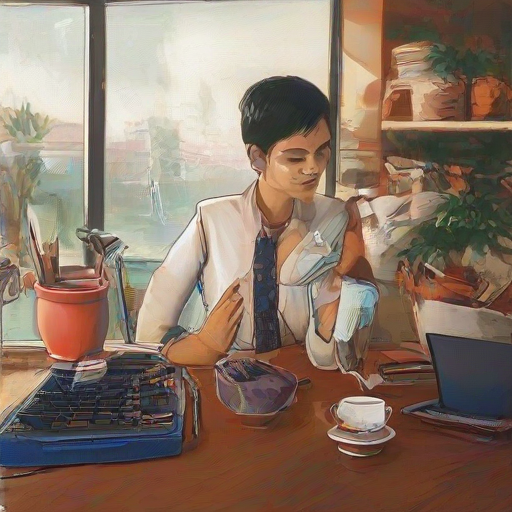

Prompt: Adorable indian cartoon depiction of an indian female corporate office employee having tea, vibrant crayon painting, office cabin, desk with laptop, cartoonish character design
Saved: C:\Users\miaoj\Desktop\Gen_AI\efficient-pixart-sigma-lora\outputs\smoke_test_r8_50\reload_generation.png
Synchronized inference time: 1.99s


In [13]:
inference_prompt_embeds = text_cache["inference_prompt_embeds"].to(DEVICE, dtype=torch.float16)
inference_attention_mask = text_cache["inference_attention_mask"].to(DEVICE)

pipe = PixArtSigmaPipeline.from_pretrained(
    CFG["COMPONENT_MODEL"],
    transformer=pipeline_transformer,
    text_encoder=None,
    tokenizer=None,
    torch_dtype=torch.float16,
    use_safetensors=True,
).to(DEVICE)
pipe.set_progress_bar_config(disable=False)

generator = torch.Generator(device=DEVICE).manual_seed(CFG["SEED"])
torch.cuda.synchronize()
inference_start = time.perf_counter()
with torch.inference_mode():
    image = pipe(
        prompt=None,
        prompt_embeds=inference_prompt_embeds,
        prompt_attention_mask=inference_attention_mask,
        num_inference_steps=CFG["INFERENCE_STEPS"],
        guidance_scale=CFG["GUIDANCE_SCALE"],
        height=CFG["RESOLUTION"],
        width=CFG["RESOLUTION"],
        use_resolution_binning=False,
        generator=generator,
    ).images[0]
torch.cuda.synchronize()
inference_seconds = time.perf_counter() - inference_start

image.save(CFG["GENERATED_IMAGE"])
display(image)
print(f"Prompt: {CFG['INFERENCE_PROMPT']}")
print(f"Saved: {CFG['GENERATED_IMAGE'].resolve()}")
print(f"Synchronized inference time: {inference_seconds:.2f}s")

## 11. Final smoke-test assertions

In [14]:
checks = {
    "python_3_11_2": sys.version_info[:3] == (3, 11, 2),
    "exactly_50_pairs": len(records) == 50,
    "rank_8_loaded": loaded_rank == 8,
    "ten_optimizer_updates": global_step == 10,
    "finite_losses": len(loss_history) == 10 and all(math.isfinite(value) for value in loss_history),
    "adapter_config_saved": adapter_config_path.exists(),
    "adapter_weights_saved": adapter_weights_path.exists(),
    "generated_image_saved": CFG["GENERATED_IMAGE"].exists(),
    "generated_image_is_512": image.size == (512, 512),
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL':4s}  {name}")
assert all(checks.values()), "Smoke test did not satisfy every success criterion."
print("\nSMOKE TEST PASSED: train -> save -> fresh reload -> generate is operational.")

PASS  python_3_11_2
PASS  exactly_50_pairs
PASS  rank_8_loaded
PASS  ten_optimizer_updates
PASS  finite_losses
PASS  adapter_config_saved
PASS  adapter_weights_saved
PASS  generated_image_saved
PASS  generated_image_is_512

SMOKE TEST PASSED: train -> save -> fresh reload -> generate is operational.


## What this test proves - and what it does not

Passing this notebook proves that the Python 3.11.2 environment, official PixArt feature format and training objective, LoRA attachment, optimizer updates, PEFT serialization, adapter reload, and inference pipeline work together.

It does **not** establish useful image quality after only 10 updates, nor does toy-data training test ink-wash adaptation. The next step is to change `DATA_MODE` to `local`, prepare 50 licensed and caption-reviewed ink-wash images, let the notebook build their T5/VAE feature cache, reuse this exact path for a short domain pilot, and only then expand to the 3x3 rank/data matrix.